# Smart Fleet on Vertica — autonomous vs. human-driven buses
### Part 3 of 3 · the visual story, told with **VerticaPy**

**The fleet:** 320 city buses on 12 lines in the Tel Aviv metropolitan area — autonomous (L4) e-buses, human-driven e-buses and human-driven diesel — streaming one IoT event per minute: **13.4 million events in 45 days**.

**The question:** what is autonomy *worth* — in safety, in energy, in uptime — and what can a city, an operator, an emergency dispatcher and a vehicle maker each learn from the very same data?

| Audience | What they get from this notebook |
|---|---|
| **Fleet operator** | live fleet board, route-adherence alerts, driver coaching list, predictive-maintenance work orders |
| **Smart-city municipality** | school-zone compliance, harsh-braking black spots, low-emission-zone exposure, lines to divert |
| **Emergency response** | units on scene, nearest trauma center, a green corridor cleared by V2X |
| **EV / AV manufacturer** | consumption vs. temperature and driving style, disengagement hot spots, component wear signatures |

**How it works:** VerticaPy gives Python a pandas-like `vDataFrame`, but every aggregation, geospatial join and model training is **pushed down to Vertica as SQL**. The 13.4 M events never leave the database — only the few hundred numbers needed to draw each chart travel to this notebook.

> Prerequisites: run `01_smart_fleet_setup.sql` and `02_smart_fleet_analytics.sql` first (they build the data and the KPI marts used below).
> All data is **synthetic**, produced by a physics-based simulator inside Vertica — the numbers are illustrative, not a field study.

## 0 · Connect

In [1]:
import os, re, warnings
warnings.filterwarnings("ignore")

import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import vertica_python
import verticapy as vp

# connection: edit here, or export VERTICA_HOST / VERTICA_PORT / VERTICA_DB / VERTICA_USER / VERTICA_PASSWORD
conn = vertica_python.connect(
    host=os.getenv("VERTICA_HOST", "127.0.0.1"), port=int(os.getenv("VERTICA_PORT", 5433)),
    database=os.getenv("VERTICA_DB", "VDB"), user=os.getenv("VERTICA_USER", "dbadmin"),
    password=os.getenv("VERTICA_PASSWORD", ""), tlsmode="prefer", autocommit=True)
vp.set_connection(conn)

pio.renderers.default = "notebook_connected"        # interactive charts, also inside the exported HTML
vp.set_option("plotting_lib", "plotly")
vp.set_option("print_info", False)
vp.set_option("tqdm", False)

print("VerticaPy", vp.__version__, "-> Vertica", ".".join(str(n) for n in vp.vertica_version()[:3]), "| database", os.getenv("VERTICA_DB", "VDB"))

VerticaPy 1.1.1 -> Vertica 26.2.0 | database VDB


In [2]:
# ---- one visual system for the whole notebook ------------------------------------------------------
SEGMENT_COLORS = {"Autonomous EV": "#2a78d6", "Human EV": "#eb6834", "Human Diesel": "#1baf7a"}   # color follows the entity
MODE_COLORS    = {"AUTONOMOUS": "#2a78d6", "HUMAN": "#eb6834"}
SEGMENTS       = list(SEGMENT_COLORS)
CRITICAL, MUTED, INK, GRID = "#d03b3b", "#8a8984", "#0b0b0b", "#e8e7e3"
BLUES = [[0.0, "rgba(205,226,251,0)"], [0.15, "#b7d3f6"], [0.4, "#6da7ec"], [0.7, "#2a78d6"], [1.0, "#0d366b"]]
vp.set_option("colors", list(SEGMENT_COLORS.values()) + ["#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"])

def style(fig, title, subtitle="", height=420, legend=True, panels=False):
    # thin marks, hairline grid, title + takeaway line; panels=True leaves room for small-multiple titles
    fig.update_layout(
        template="plotly_white", height=height, margin=dict(l=60, r=30, t=(125 if panels else 90) if subtitle else 60, b=50),
        title=dict(text=f"<b>{title}</b>" + (f"<br><span style='font-size:13px;color:#52514e'>{subtitle}</span>" if subtitle else ""),
                   x=0.01, xanchor="left", font=dict(size=17, color=INK)),
        font=dict(family="Inter, Helvetica, Arial, sans-serif", size=13, color="#52514e"),
        showlegend=legend, legend=dict(orientation="h", yanchor="bottom", y=1.0, xanchor="right", x=1.0, title_text=""),
        plot_bgcolor="#fcfcfb", paper_bgcolor="#fcfcfb", hoverlabel=dict(bgcolor="white"))
    fig.update_xaxes(gridcolor=GRID, zeroline=False, linecolor=GRID)
    fig.update_yaxes(gridcolor=GRID, zeroline=False, linecolor=GRID)
    if panels:
        fig.update_layout(legend=dict(orientation="h", yanchor="top", y=-0.22, xanchor="center", x=0.5))
        fig.update_annotations(font=dict(size=13, color=INK))
    return fig

def q(sql):
    # run SQL in Vertica, return a small pandas frame (numerics as float)
    df = vp.vDataFrame(sql).to_pandas()
    for c in df.columns:
        if not (pd.api.types.is_numeric_dtype(df[c]) or pd.api.types.is_datetime64_any_dtype(df[c]) or pd.api.types.is_bool_dtype(df[c])):
            try:
                df[c] = pd.to_numeric(df[c])          # Vertica NUMERIC arrives as Decimal / text
            except (ValueError, TypeError):
                pass
    return df

def wkt_coords(wkt):
    pts = re.findall(r"(-?\d+\.?\d*)\s+(-?\d+\.?\d*)", wkt)
    return [float(x) for x, _ in pts], [float(y) for _, y in pts]

def base_map(title, subtitle="", height=620, zoom=11.2, center=(32.075, 34.81), zones=True):
    # bus lines + geofences from the GEOMETRY columns (ST_AsText), drawn on an OpenStreetMap-based layer
    fig = go.Figure()
    if zones:
        zdf = q("SELECT zone_name, zone_type, ST_AsText(zone_geom) AS wkt FROM FLEET.zones")
        fills = {"SCHOOL": "rgba(237,161,0,0.30)", "HOSPITAL": "rgba(208,59,59,0.18)", "LOW_EMISSION": "rgba(27,175,122,0.07)",
                 "COMPLEX_JUNCTION": "rgba(74,58,167,0.22)", "DEPOT": "rgba(82,81,78,0.25)"}
        for zt, grp in zdf.groupby("zone_type"):
            lon, lat, txt = [], [], []
            for _, r in grp.iterrows():
                x, y = wkt_coords(r.wkt); lon += x + [None]; lat += y + [None]; txt += [r.zone_name] * len(x) + [None]
            fig.add_trace(go.Scattermap(lon=lon, lat=lat, mode="lines", fill="toself", fillcolor=fills[zt], text=txt, hoverinfo="text",
                                        line=dict(width=1, color=fills[zt].replace(re.search(r",[\d.]+\)$", fills[zt]).group(0), ",0.9)")),
                                        name=zt.replace("_", " ").title() + " zone"))
    rdf = q("SELECT line_no, route_name, ST_AsText(route_geom) AS wkt FROM FLEET.routes")
    lon, lat, txt = [], [], []
    for _, r in rdf.iterrows():
        x, y = wkt_coords(r.wkt); lon += x + [None]; lat += y + [None]; txt += [f"Line {r.line_no} · {r.route_name}"] * len(x) + [None]
    fig.add_trace(go.Scattermap(lon=lon, lat=lat, mode="lines", line=dict(width=2, color="#52514e"), opacity=0.55, text=txt, hoverinfo="text", name="Bus lines"))
    style(fig, title, subtitle, height)
    fig.update_layout(map=dict(style="carto-positron", zoom=zoom, center=dict(lat=center[0], lon=center[1])),
                      margin=dict(l=0, r=0, b=0), legend=dict(orientation="v", yanchor="top", y=0.98, xanchor="left", x=0.01, bgcolor="rgba(255,255,255,0.85)"))
    return fig

## 1 · 13.4 million events — and zero rows in Python
A `vDataFrame` is a *pointer* to data in Vertica. `describe()` below scans every event, in the database, and returns a handful of numbers.

13,352,229 events x 23 columns  |  rows held in Python memory: 0


,123event_idInteger,123vehicle_idInteger,📅tsTimestamp(29),🌎latFloat(22),🌎lonFloat(22),123speed_kmhNumeric(7),123accel_ms2Numeric(7),123odometer_kmNumeric(11),123power_kwNumeric(8),123fuel_lphNumeric(7),123energy_pctNumeric(7),123motor_temp_cNumeric(7),123batt_temp_cNumeric(7),123vibration_gNumeric(7),123tire_psiNumeric(7),123outside_temp_cNumeric(6),123passengersInteger,123brake_pedalInteger,123abs_onInteger,123wipers_onInteger,123headlamps_onInteger,123doors_openInteger,123av_disengageInteger
1,11366402,1001,2026-09-09 06:01:13,32.06972,34.771844,33.4,-0.21,266265.8,-7.3,[null],97.0,51.0,24.9,0.471,111.7,15.4,10,1,0,0,1,0,0
2,11366403,1001,2026-09-09 06:02:14,32.070699,34.772291,0.0,-0.03,266265.9,4.4,[null],97.0,50.0,24.1,0.248,111.9,14.8,12,1,0,0,1,1,0
3,11366404,1001,2026-09-09 06:03:10,32.073404,34.773536,29.3,-0.35,266266.2,-14.1,[null],97.1,49.8,24.8,0.457,111.5,14.6,14,1,0,0,1,0,0
4,11366406,1001,2026-09-09 06:05:03,32.076804,34.774175,30.2,-0.35,266266.6,-13.6,[null],97.1,51.8,24.5,0.447,112.2,14.5,10,1,0,0,1,0,0
5,11366407,1001,2026-09-09 06:06:13,32.077578,34.774018,0.5,0.58,266266.7,5.7,[null],97.1,50.3,25.0,0.284,111.8,15.3,18,0,0,0,1,0,0

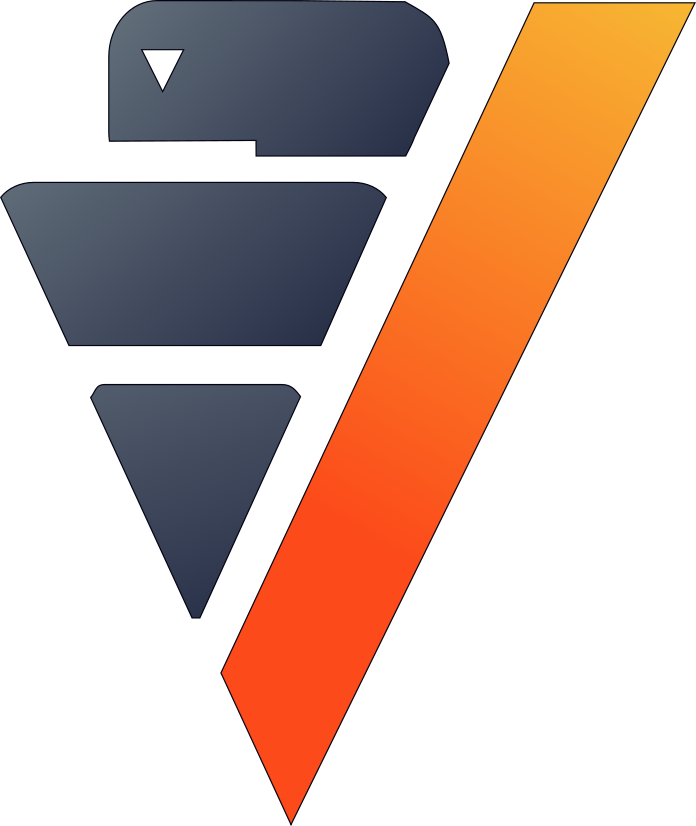

In [3]:
telemetry = vp.vDataFrame("FLEET.telemetry")
print(f"{telemetry.shape()[0]:,} events x {telemetry.shape()[1]} columns  |  rows held in Python memory: 0")
telemetry.head(5)

,count,mean,std,min,approx_25%,approx_50%,approx_75%,max
"""speed_kmh""",13352229,14.976977020091,18.450800769392,0.0,0.0,0.7,31.6,93.7
"""accel_ms2""",13352229,-0.0340098630723035,0.623164776489784,-6.5,-0.08,0.0,0.07,4.2
"""power_kw""",9185319,16.0917344079171,38.556932505079,-85.4,2.7,4.4,19.5,275.3
"""motor_temp_c""",13352229,64.3843681380793,16.1126292061252,41.1,52.2,56.3,84.9,118.5
"""vibration_g""",13352229,0.408269902126445,0.127469965997014,0.178,0.295,0.394,0.498,1.059
"""tire_psi""",13352229,112.07687402605,1.86433754829101,91.0,111.0,112.1,113.3,117.2

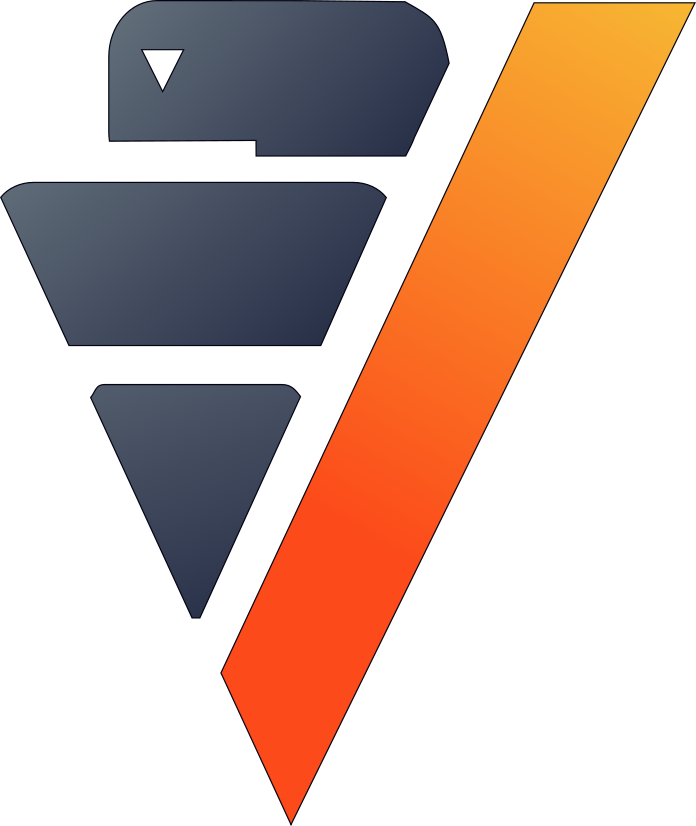

In [4]:
telemetry[["speed_kmh", "accel_ms2", "power_kw", "motor_temp_c", "vibration_g", "tire_psi"]].describe(method="numerical")

Curious what VerticaPy actually sends to the database? Every `vDataFrame` can show the SQL it stands for:

-- generated by VerticaPy:
(
   SELECT
     * 
   FROM
 (
   SELECT
     "fleet_segment",
     "drive_mode",
     "powertrain",
     COUNT(*) AS vehicles 
   FROM
 "FLEET"."vehicles" 
   GROUP BY 1,
     2,
     3) 
VERTICAPY_SUBTABLE 
   ORDER BY "fleet_segment") 
VERTICAPY_SUBTABLE


,Abcfleet_segmentVarchar(24),Abcdrive_modeVarchar(12),AbcpowertrainVarchar(8),123vehiclesInteger
1,Autonomous EV,AUTONOMOUS,EV,100
2,Human Diesel,HUMAN,DIESEL,100
3,Human EV,HUMAN,EV,120

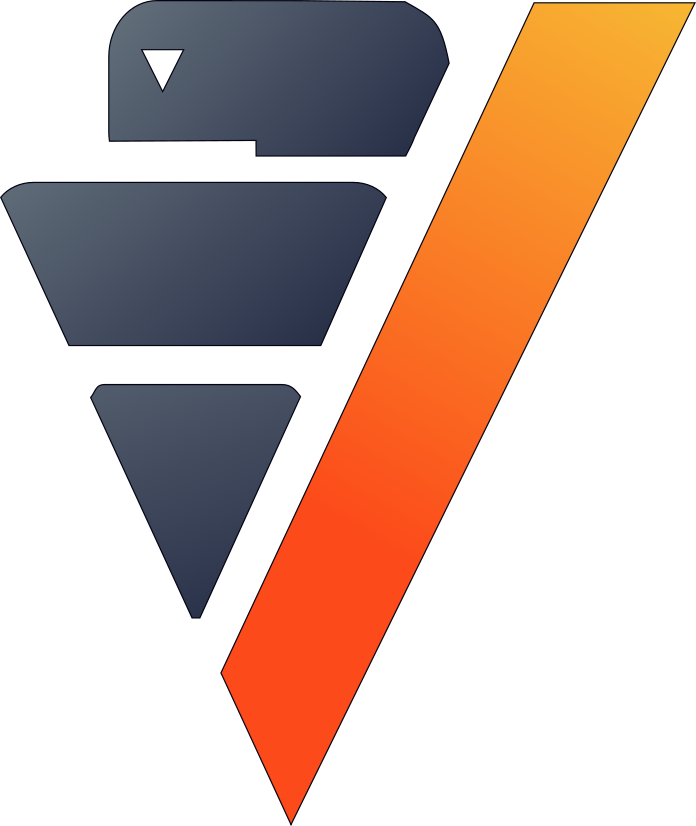

In [5]:
fleet = vp.vDataFrame("FLEET.vehicles").groupby(["fleet_segment", "drive_mode", "powertrain"], ["COUNT(*) AS vehicles"]).sort("fleet_segment")
print("-- generated by VerticaPy:")
print(fleet.current_relation())
fleet

## 2 · The digital twin on a map
Bus lines are `LINESTRING`s, geofences are `POLYGON`s, hospitals / depots / chargers are `POINT`s — native `GEOMETRY` / `GEOGRAPHY` types in Vertica.
The dots are the **latest known position of every vehicle**: one Top-K query (`LIMIT 1 OVER (PARTITION BY vehicle_id ORDER BY ts DESC)`).

In [6]:
live = q('''
    SELECT v.plate, v.fleet_segment, r.line_no, l.ts, l.lat, l.lon, l.speed_kmh, l.energy_pct, l.passengers
    FROM (SELECT * FROM FLEET.telemetry LIMIT 1 OVER (PARTITION BY vehicle_id ORDER BY ts DESC)) l
    JOIN FLEET.vehicles v USING (vehicle_id) JOIN FLEET.routes r USING (route_id)''')

fig = base_map("Live fleet board", f"{len(live)} vehicles · last fix {live.ts.max():%Y-%m-%d %H:%M} · hover any bus")
for seg in SEGMENTS:
    d = live[live.fleet_segment == seg]
    fig.add_trace(go.Scattermap(lon=d.lon, lat=d.lat, mode="markers", name=seg,
        marker=dict(size=9, color=SEGMENT_COLORS[seg], opacity=0.9),
        text=[f"<b>{p}</b> · line {l}<br>{s:.0f} km/h · {e:.0f}% energy · {x} passengers" for p, l, s, e, x in zip(d.plate, d.line_no, d.speed_kmh, d.energy_pct, d.passengers)],
        hoverinfo="text"))
fac = q("SELECT facility_name, facility_type, lon, lat FROM FLEET.facilities")
fig.add_trace(go.Scattermap(lon=fac.lon, lat=fac.lat, mode="markers", name="Hospitals · depots · chargers",
    marker=dict(size=13, color="#0b0b0b", symbol="circle", opacity=0.75), text=fac.facility_name + " (" + fac.facility_type.str.lower().str.replace("_", " ") + ")", hoverinfo="text"))
fig

## 3 · Geofencing at IoT scale — school zones
`verticapy.sql.geo` wraps Vertica's spatial index: `create_index` (STV_Create_Index) and `intersect` (STV_Intersect).
Every school-hours GPS fix of the fleet is tested against the school-zone polygons **in the database, in parallel** — then we simply look at how fast each group drives inside a 30 km/h zone.

In [7]:
from verticapy.sql.geo import create_index, intersect
import time

school_zones = vp.vDataFrame("SELECT zone_id, zone_geom FROM FLEET.zones WHERE zone_type = 'SCHOOL'")
create_index(school_zones, gid="zone_id", g="zone_geom", index="vpy_school_zones", overwrite=True)

fixes = vp.vDataFrame("SELECT event_id, lon, lat FROM FLEET.telemetry WHERE HOUR(ts) BETWEEN 7 AND 16 AND speed_kmh > 0")
vp.drop("FLEET.vpy_school_hits", method="table")
t0 = time.time()
hits = intersect(fixes, index="vpy_school_zones", gid="event_id", x="lon", y="lat")     # lazy: just builds the SQL
hits.to_db("FLEET.vpy_school_hits", relation_type="table")                              # runs STV_Intersect in Vertica
n_hits = vp.vDataFrame("FLEET.vpy_school_hits").shape()[0]
print(f"{fixes.shape()[0]:,} GPS fixes tested against {school_zones.shape()[0]} polygons -> {n_hits:,} inside a school zone  ({time.time() - t0:.1f} s)")

4,206,155 GPS fixes tested against 10 polygons -> 247,404 inside a school zone  (0.3 s)


In [8]:
speeds = q('''
    SELECT v.drive_mode, FLOOR(t.speed_kmh / 2) * 2 AS kmh, COUNT(*) AS n
    FROM FLEET.vpy_school_hits h JOIN FLEET.telemetry t ON t.event_id = h.point_id JOIN FLEET.vehicles v ON v.vehicle_id = t.vehicle_id
    GROUP BY 1, 2''')
speeds["pct"] = 100 * speeds.n / speeds.groupby("drive_mode").n.transform("sum")
viol = speeds[speeds.kmh >= 34].groupby("drive_mode").pct.sum()

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08)
for i, mode in enumerate(["AUTONOMOUS", "HUMAN"], start=1):
    d = speeds[speeds.drive_mode == mode].sort_values("kmh")
    fig.add_trace(go.Bar(x=d.kmh + 1, y=d.pct, name=mode.title(), marker=dict(color=MODE_COLORS[mode], line=dict(width=1, color="#fcfcfb")),
                         hovertemplate="%{x:.0f} km/h · %{y:.1f}% of readings<extra>" + mode.title() + "</extra>"), row=i, col=1)
    fig.add_vline(x=30, line=dict(color=CRITICAL, width=1.5), row=i, col=1)
    fig.add_annotation(x=76, y=d.pct.max() * 0.8, xanchor="right", showarrow=False, row=i, col=1,
                       text=f"<b>{mode.title()}</b> · {viol.get(mode, 0):.1f}% of readings above 33 km/h", font=dict(color=INK, size=14))
fig.add_annotation(x=30, y=1.05, yref="paper", text="limit 30 km/h", showarrow=False, font=dict(color=CRITICAL))
fig.update_yaxes(title_text="% of readings"); fig.update_xaxes(title_text="speed inside school zones, km/h", row=2, col=1, range=[0, 78])
style(fig, "School zones, school hours: who respects 30 km/h?", f"The autonomous stack never exceeds the limit · human drivers do in {viol.get('HUMAN', 0):.0f}% of their readings", height=480, legend=False)

## 4 · Where the city should act — harsh-braking black spots
Every harsh brake (deceleration ≥ 3.2 m/s²) is binned **in the database** with `ST_GeoHash` (~150 m cells). Only the cell counts travel to the notebook.
The hot cells line up with three complex junctions: candidates for signal re-timing, lane repainting, or a protected bus lane.

In [9]:
cells = q('''
    SELECT ST_GeoHash(STV_GeometryPoint(lon, lat) USING PARAMETERS numchars = 7) AS geohash,
           AVG(lat) AS lat, AVG(lon) AS lon, COUNT(*) AS harsh_brakes
    FROM FLEET.telemetry WHERE accel_ms2 <= -3.2 GROUP BY 1''')
top = cells.nlargest(3, "harsh_brakes")
landmarks = q("SELECT zone_name, center_lon, center_lat FROM FLEET.zones WHERE zone_type <> 'LOW_EMISSION'")
hot = list(dict.fromkeys(landmarks.zone_name[((landmarks.center_lon - r.lon) ** 2 + (landmarks.center_lat - r.lat) ** 2).idxmin()] for r in cells.nlargest(8, "harsh_brakes").itertuples()))

fig = base_map("Harsh-braking black spots", f"{int(cells.harsh_brakes.sum()):,} harsh brakes in {len(cells):,} geohash cells · hottest: " + " · ".join(hot[:3]), zoom=11.8, center=(32.068, 34.80))
fig.add_trace(go.Densitymap(lon=cells.lon, lat=cells.lat, z=cells.harsh_brakes, radius=16, colorscale=BLUES, zmin=0, zmax=float(cells.harsh_brakes.quantile(0.995)),
                            colorbar=dict(title="harsh brakes<br>per cell", thickness=12, len=0.5, x=0.99, xanchor="right", bgcolor="rgba(255,255,255,0.85)"), hoverinfo="skip", name="density"))
fig.add_trace(go.Scattermap(lon=top.lon, lat=top.lat, mode="markers", marker=dict(size=13, color=CRITICAL), name="Top 3 cells",
                            text=[f"{int(n)} harsh brakes in this ~150 m cell" for n in top.harsh_brakes], hoverinfo="text"))
fig

## 5 · For the AV maker — where does the self-driving stack give up?
A *disengagement* is the moment the safety operator has to take over. Normalised by distance driven, three junctions are **~20× harder** than the rest of the network.

In [10]:
dis = q('''
    SELECT NVL(z.zone_name, 'Open road (everywhere else)') AS location,
           SUM(t.av_disengage) AS disengagements, SUM(t.speed_kmh / 60.0) AS km
    FROM FLEET.telemetry t JOIN FLEET.vehicles v ON v.vehicle_id = t.vehicle_id AND v.drive_mode = 'AUTONOMOUS'
    LEFT JOIN (SELECT h.event_id, g.zone_name FROM FLEET.zone_hits h JOIN FLEET.zones g ON g.zone_id = h.zone_id AND g.zone_type = 'COMPLEX_JUNCTION') z
           ON z.event_id = t.event_id
    GROUP BY 1''')
dis["per_1000km"] = 1000 * dis.disengagements / dis.km
dis = dis.sort_values("per_1000km")
fig = go.Figure(go.Bar(y=dis.location, x=dis.per_1000km, orientation="h", marker_color=SEGMENT_COLORS["Autonomous EV"], width=0.55,
                       text=[f"{v:.1f}  ({int(n)} events)" for v, n in zip(dis.per_1000km, dis.disengagements)], textposition="outside", cliponaxis=False,
                       hovertemplate="%{y}<br>%{x:.1f} per 1,000 km<extra></extra>"))
fig.update_xaxes(title_text="disengagements per 1,000 autonomous km", range=[0, dis.per_1000km.max() * 1.3])
style(fig, "AV disengagements per 1,000 km, by location", "Retrain perception and planning on these three junctions first", height=330, legend=False)

## 6 · Route adherence — an unauthorized detour
Distance from every GPS fix to its assigned `LINESTRING` (`ST_Distance` on the `GEOGRAPHY` spheroid → true meters). Here is the worst offender of the last week, replayed.

In [11]:
worst = q('''
    SELECT t.vehicle_id, v.plate, v.route_id, t.ts::date AS day, MAX(ST_Distance(r.route_geog, STV_GeographyPoint(t.lon, t.lat))) AS max_off_m
    FROM FLEET.telemetry t JOIN FLEET.vehicles v ON v.vehicle_id = t.vehicle_id JOIN FLEET.routes r ON r.route_id = v.route_id
    WHERE ST_Distance(r.route_geom, STV_GeometryPoint(t.lon, t.lat)) > 0.002           -- planar pre-filter (~200 m)
    GROUP BY 1, 2, 3, 4 ORDER BY 5 DESC LIMIT 1''').iloc[0]
track = q(f'''
    SELECT t.ts, t.lat, t.lon, ST_Distance(r.route_geog, STV_GeographyPoint(t.lon, t.lat)) AS off_m
    FROM FLEET.telemetry t JOIN FLEET.routes r ON r.route_id = {int(worst.route_id)}
    WHERE t.vehicle_id = {int(worst.vehicle_id)} AND t.ts::date = '{worst.day}' AND HOUR(t.ts) BETWEEN 13 AND 15 ORDER BY t.ts''')
off = track[track.off_m > 250]

fig = base_map(f"{worst.plate} left its line on {worst.day}", f"{len(off)} minutes off route · up to {worst.max_off_m:.0f} m away · first alert {off.ts.min():%H:%M}",
               zoom=12.6, center=(float(track.lat.mean()), float(track.lon.mean())), zones=False)
fig.add_trace(go.Scattermap(lon=track.lon, lat=track.lat, mode="lines+markers", name="GPS track 13:00-16:00", line=dict(width=2, color=SEGMENT_COLORS["Human EV"]), marker=dict(size=5)))
fig.add_trace(go.Scattermap(lon=off.lon, lat=off.lat, mode="markers", name="Off route (> 250 m) — alert", marker=dict(size=10, color=CRITICAL),
                            text=[f"{t:%H:%M} · {m:.0f} m off route" for t, m in zip(off.ts, off.off_m)], hoverinfo="text"))
fig

## 7 · Autonomous vs. human — same lines, same timetable, same weather
Every line runs the same mix of vehicles, so the comparison is like-for-like. The safety score is `100 − 9·harsh brakes/100 km − 6·harsh accelerations/100 km − 2.5·speeding %`.

In [12]:
score = vp.vDataFrame("FLEET.vehicle_score")
five = score.groupby("fleet_segment", ["MIN(safety_score) AS lo", "APPROXIMATE_PERCENTILE(safety_score USING PARAMETERS percentile = 0.25) AS q1",
                                       "APPROXIMATE_MEDIAN(safety_score) AS med", "APPROXIMATE_PERCENTILE(safety_score USING PARAMETERS percentile = 0.75) AS q3",
                                       "MAX(safety_score) AS hi"]).to_pandas().set_index("fleet_segment").astype(float).loc[SEGMENTS]
fig = go.Figure()
for seg, r in five.iterrows():
    fig.add_trace(go.Box(x=[seg], lowerfence=[r.lo], q1=[r.q1], median=[r.med], q3=[r.q3], upperfence=[r.hi], name=seg,
                         line=dict(color=SEGMENT_COLORS[seg], width=2), fillcolor="rgba(0,0,0,0)", width=0.45))
    fig.add_annotation(x=seg, y=r.med, text=f"median {r.med:.0f}", xshift=120, showarrow=False, font=dict(color=INK))
fig.update_yaxes(title_text="safety score per vehicle (100 = flawless)", range=[35, 102])
style(fig, "Safety score per vehicle", "Whiskers = worst and best vehicle · autonomy is not just better on average, it is consistent: the worst AV beats the best human driver", height=430, legend=False)

In [13]:
kpi = q("SELECT * FROM FLEET.segment_scorecard").set_index("fleet_segment").loc[SEGMENTS]
panels = [("harsh_brakes_100km", "Harsh brakes / 100 km", "{:.2f}"), ("speeding_pct", "Time above limit, %", "{:.2f}"),
          ("incidents_100k_km", "Incidents / 100,000 km", "{:.1f}"), ("jerkiness", "Jerkiness (accel. std-dev)", "{:.2f}")]
fig = make_subplots(rows=1, cols=4, subplot_titles=[p[1] for p in panels], horizontal_spacing=0.06)
for i, (col, _, f) in enumerate(panels, start=1):
    fig.add_trace(go.Bar(x=SEGMENTS, y=kpi[col], marker_color=[SEGMENT_COLORS[s] for s in SEGMENTS], width=0.6, showlegend=False,
                         text=[f.format(v) for v in kpi[col]], textposition="outside", cliponaxis=False, hovertemplate="%{x}: %{y:.2f}<extra></extra>"), row=1, col=i)
    fig.update_yaxes(range=[0, float(kpi[col].max()) * 1.25], showticklabels=False, row=1, col=i)
fig.update_xaxes(tickangle=-25)
style(fig, "The safety scorecard", "Lower is better on every panel · each KPI on its own scale", height=430, legend=False, panels=True)

In [14]:
acc = q('''
    SELECT v.drive_mode, ROUND(t.accel_ms2, 1) AS accel, COUNT(*) AS n
    FROM FLEET.telemetry t JOIN FLEET.vehicles v ON v.vehicle_id = t.vehicle_id
    WHERE t.speed_kmh > 0 GROUP BY 1, 2''')
acc["pct"] = 100 * acc.n / acc.groupby("drive_mode").n.transform("sum")
fig = go.Figure()
for mode in ["HUMAN", "AUTONOMOUS"]:
    d = acc[acc.drive_mode == mode].sort_values("accel")
    fig.add_trace(go.Scatter(x=d.accel, y=d.pct, mode="lines", name=mode.title(), line=dict(width=2, color=MODE_COLORS[mode]),
                             hovertemplate="%{x:.1f} m/s² · %{y:.3f}% of readings<extra>" + mode.title() + "</extra>"))
tail = acc[acc.accel <= -3.2].groupby("drive_mode").pct.sum()
fig.add_vrect(x0=-6.7, x1=-3.2, fillcolor=CRITICAL, opacity=0.07, line_width=0)
fig.add_annotation(x=-4.9, y=0.93, yref="paper", text="harsh-brake territory (≤ −3.2 m/s²)", showarrow=False, font=dict(color=CRITICAL))
fig.update_yaxes(type="log", title_text="% of moving readings (log scale)", range=[-4.3, 1.3]); fig.update_xaxes(title_text="longitudinal acceleration, m/s²", range=[-6.7, 4.4])
style(fig, "The smoothness fingerprint", f"13 M accelerometer readings, binned in-database · the autonomous curve is narrower, and its harsh-brake tail is {tail['HUMAN'] / tail['AUTONOMOUS']:.0f}× thinner", height=420)

## 8 · Energy — smooth driving is cheap driving
Battery power is integrated per vehicle and day (SQL window functions in the KPI mart). Three views: by driving style, by temperature, and over one service day.

In [15]:
ev = vp.vDataFrame("SELECT * FROM FLEET.vehicle_score WHERE powertrain = 'EV'")
fig = ev.scatter(["jerkiness", "kwh_km"], by="fleet_segment")
fig.update_traces(marker=dict(size=8, line=dict(width=1, color="#fcfcfb")))
fig.update_xaxes(title_text="jerkiness — std-dev of acceleration, m/s²"); fig.update_yaxes(title_text="net energy, kWh per km")
style(fig, "Energy use vs. driving smoothness — one dot per e-bus", "The autonomous buses sit together at the efficient end · the human spread is the coaching opportunity", height=440)

In [16]:
temp = q('''
    SELECT v.fleet_segment, FLOOR(d.avg_out_temp / 3) * 3 + 1.5 AS temp_c, SUM(d.kwh_out - d.kwh_regen) / SUM(d.km) AS kwh_km, COUNT(*) AS vehicle_days
    FROM FLEET.vehicle_day d JOIN FLEET.vehicles v USING (vehicle_id) WHERE v.powertrain = 'EV' GROUP BY 1, 2 HAVING COUNT(*) > 40''')
fig = go.Figure()
for seg in ["Autonomous EV", "Human EV"]:
    d = temp[temp.fleet_segment == seg].sort_values("temp_c")
    fig.add_trace(go.Scatter(x=d.temp_c, y=d.kwh_km, mode="lines+markers", name=seg, line=dict(width=2, color=SEGMENT_COLORS[seg]), marker=dict(size=8),
                             hovertemplate="%{x:.0f} °C · %{y:.3f} kWh/km<extra>" + seg + "</extra>"))
    fig.add_annotation(x=d.temp_c.iloc[-1], y=d.kwh_km.iloc[-1], text=f"  {seg}", xanchor="left", showarrow=False, font=dict(color=INK))
fig.update_xaxes(title_text="average ambient temperature of the day, °C", range=[temp.temp_c.min() - 1, temp.temp_c.max() + 4]); fig.update_yaxes(title_text="net energy, kWh per km", rangemode="tozero")
style(fig, "Consumption vs. ambient temperature", "HVAC load bends both curves upward away from ~20 °C · the gap between the curves is pure driving style", height=420, legend=False)

In [17]:
pair = q('''
    SELECT s.vehicle_id, s.plate, s.fleet_segment, s.safety_score FROM FLEET.vehicle_score s JOIN FLEET.vehicles v USING (vehicle_id)
    WHERE v.route_id = 7 AND s.powertrain = 'EV'
    LIMIT 1 OVER (PARTITION BY s.fleet_segment ORDER BY CASE WHEN s.drive_mode = 'HUMAN' THEN s.safety_score ELSE -s.safety_score END)''')
ids = ",".join(str(int(i)) for i in pair.vehicle_id)
soc = q(f'''
    SELECT vehicle_id, slice AS ts, TS_FIRST_VALUE(energy_pct, 'LINEAR') AS soc
    FROM FLEET.telemetry WHERE vehicle_id IN ({ids}) AND ts::date = (SELECT MAX(ts)::date FROM FLEET.telemetry)
    TIMESERIES slice AS '10 minutes' OVER (PARTITION BY vehicle_id ORDER BY ts)''').dropna()
fig = go.Figure()
for _, r in pair.iterrows():
    d = soc[soc.vehicle_id == r.vehicle_id].sort_values("ts")
    fig.add_trace(go.Scatter(x=d.ts, y=d.soc, mode="lines", name=f"{r.fleet_segment} · {r.plate}", line=dict(width=2, color=SEGMENT_COLORS[r.fleet_segment]),
                             hovertemplate="%{x|%H:%M} · %{y:.0f}%<extra>" + r.plate + "</extra>"))
    fig.add_annotation(x=d.ts.iloc[-1], y=d.soc.iloc[-1], text=f"  {d.soc.iloc[-1]:.0f}%", xanchor="left", showarrow=False, font=dict(color=INK, size=14))
fig.add_hline(y=15, line=dict(color=CRITICAL, width=1)); fig.add_annotation(x=soc.ts.min(), y=15, text="15% reserve", xanchor="left", yanchor="bottom", showarrow=False, font=dict(color=CRITICAL))
fig.update_yaxes(title_text="state of charge, %", range=[0, 100])
style(fig, "One service day on the Airport Express: state of charge", "Same line, same timetable · the least smooth human driver comes home on fumes (TIMESERIES gap-filling, 10-minute grid)", height=420)

## 9 · Machine learning, inside the database
VerticaPy's scikit-learn-style classes call Vertica's native, distributed ML functions. Models are database objects: train here, score anywhere with SQL.

### 9.1 · K-means discovers driving styles
The algorithm sees four behaviour features per vehicle — and is **not** told which buses are autonomous.

In [18]:
from verticapy.machine_learning.vertica import KMeans
from verticapy.machine_learning.model_selection import elbow

style_features = ["hb_100km", "ha_100km", "speeding_pct", "jerkiness"]
fig = elbow("FLEET.vehicle_style_norm", style_features, n_cluster=(1, 8))
fig.update_traces(line=dict(color="#2a78d6", width=2), marker=dict(size=9, color="#2a78d6", line=dict(width=2, color="#fcfcfb")))
fig.update_yaxes(title_text="between-cluster SS / total SS"); fig.update_xaxes(title_text="number of clusters")
style(fig, "How many driving styles are there?", "Elbow method on z-scored features: the gain flattens after 3 clusters", height=360, legend=False)

In [19]:
km = KMeans("FLEET.vpy_style_kmeans", overwrite_model=True, n_cluster=3, init="kmeanspp")
km.fit("FLEET.vehicle_style_norm", style_features)
clustered = km.predict(vp.vDataFrame("FLEET.vehicle_style_norm"), name="cluster")
vp.drop("FLEET.vpy_vehicle_clusters", method="table")
clustered.to_db("FLEET.vpy_vehicle_clusters", relation_type="table")

pts = q('''
    SELECT c.cluster, s.drive_mode, s.plate, s.jerkiness, s.hb_100km, s.safety_score,
           DENSE_RANK() OVER (ORDER BY cs.avg_score DESC) AS style_rank
    FROM FLEET.vpy_vehicle_clusters c JOIN FLEET.vehicle_score s USING (vehicle_id)
    JOIN (SELECT c2.cluster, AVG(s2.safety_score) AS avg_score FROM FLEET.vpy_vehicle_clusters c2 JOIN FLEET.vehicle_score s2 USING (vehicle_id) GROUP BY 1) cs ON cs.cluster = c.cluster''')
names = {1: "A · smooth", 2: "B · average", 3: "C · aggressive"}
fig = make_subplots(rows=1, cols=3, shared_yaxes=True, shared_xaxes=True, horizontal_spacing=0.03,
                    subplot_titles=[f"{names[k]} — {int((pts.style_rank == k).sum())} vehicles, {int(((pts.style_rank == k) & (pts.drive_mode == 'AUTONOMOUS')).sum())} autonomous" for k in (1, 2, 3)])
for k in (1, 2, 3):
    for mode in ["HUMAN", "AUTONOMOUS"]:
        d = pts[(pts.style_rank == k) & (pts.drive_mode == mode)]
        fig.add_trace(go.Scatter(x=d.jerkiness, y=d.hb_100km, mode="markers", name=mode.title(), legendgroup=mode, showlegend=(k == 1),
                                 marker=dict(size=8, color=MODE_COLORS[mode], line=dict(width=1, color="#fcfcfb")),
                                 text=d.plate, hovertemplate="%{text}<br>jerkiness %{x:.2f} · %{y:.2f} harsh brakes/100 km<extra></extra>"), row=1, col=k)
fig.update_xaxes(title_text="jerkiness", matches="x"); fig.update_yaxes(title_text="harsh brakes / 100 km", col=1)
style(fig, "Three driving styles, discovered without labels", "Every autonomous bus lands in cluster A, next to the smoothest human drivers · cluster C is the coaching list", height=470, panels=True)

### 9.2 · Predictive maintenance — will this bus break down within 7 days?
Features compare each sensor with **the same vehicle 4–14 days earlier** (SQL window functions, built in part 2). First, what a developing fault looks like:

In [20]:
cases = q('''
    SELECT m.component, m.vehicle_id, v.plate, m.event_ts::date AS fail_day
    FROM FLEET.maintenance_log m JOIN FLEET.vehicles v USING (vehicle_id)
    WHERE m.event_type = 'BREAKDOWN' AND m.component <> 'ELECTRICAL' AND m.event_ts::date > (SELECT MIN(day) + 16 FROM FLEET.vehicle_day)
    LIMIT 1 OVER (PARTITION BY m.component ORDER BY m.event_ts)''')
signal = {"COOLING": ("avg_motor_temp", "motor temperature, °C"), "DRIVETRAIN": ("avg_vib", "vibration, g"), "TIRE": ("avg_psi", "tire pressure, psi")}
fig = make_subplots(rows=1, cols=3, horizontal_spacing=0.07, subplot_titles=[f"{r.component.title()} fault · {r.plate}" for _, r in cases.iterrows()])
for i, (_, r) in enumerate(cases.iterrows(), start=1):
    col, label = signal[r.component]
    d = q(f"SELECT day, {col} AS y FROM FLEET.vehicle_day WHERE vehicle_id = {int(r.vehicle_id)} AND day BETWEEN '{r.fail_day}'::date - 16 AND '{r.fail_day}'::date - 1 ORDER BY day")
    d["days_before"] = (pd.to_datetime(d.day) - pd.Timestamp(r.fail_day)).dt.days
    fig.add_trace(go.Scatter(x=d.days_before, y=d.y, mode="lines+markers", line=dict(width=2, color=CRITICAL), marker=dict(size=6), showlegend=False,
                             hovertemplate="day %{x}: %{y:.2f}<extra></extra>"), row=1, col=i)
    fig.update_yaxes(title_text=label, row=1, col=i); fig.update_xaxes(title_text="days before the breakdown", row=1, col=i)
style(fig, "Three wear signatures, 16 days before the breakdown", "Daily sensor averages of three breakdowns from the workshop log · the drift starts 7-10 days ahead", height=410, legend=False, panels=True)

In [21]:
from verticapy.machine_learning.vertica import RandomForestClassifier, XGBClassifier, LogisticRegression

pdm_features = ["vib_vs_baseline", "temp_vs_baseline", "psi_vs_baseline", "vib_trend_2d", "temp_trend_2d", "psi_trend_2d",
                "max_vib", "max_motor_temp", "min_psi", "hb_100km", "avg_out_temp"]
train, test = vp.vDataFrame("FLEET.pdm_train"), vp.vDataFrame("FLEET.pdm_test")     # split BY VEHICLE: 70% / 30%
print(f"train: {train.shape()[0]:,} vehicle-days, {int(train['fails_within_7d'].sum())} positives  |  test: {test.shape()[0]:,} vehicle-days, {int(test['fails_within_7d'].sum())} positives")

models = {
    "Random forest":       RandomForestClassifier("FLEET.vpy_pdm_rf",  overwrite_model=True, n_estimators=80, max_depth=8, sample=0.8),
    "XGBoost":             XGBClassifier("FLEET.vpy_pdm_xgb",          overwrite_model=True, max_ntree=60, max_depth=5, learning_rate=0.2),
    "Logistic regression": LogisticRegression("FLEET.vpy_pdm_logit",   overwrite_model=True, max_iter=200),
}
board = []
for name, model in models.items():
    t0 = time.time(); model.fit(train, pdm_features, "fails_within_7d", test)
    board.append({"model": name, "train seconds": round(time.time() - t0, 1), "AUC": model.score(metric="auc"), "PR-AUC": model.score(metric="prc_auc"),
                  "precision @0.4": model.score(metric="precision", cutoff=0.4), "recall @0.4": model.score(metric="recall", cutoff=0.4)})
pd.DataFrame(board).set_index("model").style.format("{:.3f}", subset=["AUC", "PR-AUC", "precision @0.4", "recall @0.4"]).background_gradient(cmap="Blues", subset=["AUC", "PR-AUC"])

train: 6,612 vehicle-days, 182 positives  |  test: 2,962 vehicle-days, 73 positives


,train seconds,AUC,PR-AUC,precision @0.4,recall @0.4
model,,,,,
Random forest,1.200000,0.942,0.848,0.917,0.753
XGBoost,3.800000,0.931,0.827,0.982,0.767
Logistic regression,0.100000,0.933,0.857,0.894,0.808


In [22]:
rf = models["Random forest"]
fig = rf.roc_curve()
fig.update_traces(fill="none", line=dict(width=2)); fig.layout.annotations = []
if len(fig.data) > 1: fig.data[1].line.color = MUTED                                   # the "coin flip" diagonal stays recessive
fig.update_xaxes(title_text="false positive rate", range=[-0.01, 1]); fig.update_yaxes(title_text="true positive rate (recall)", range=[0, 1.02])
style(fig, "Random forest — ROC curve on vehicles the model has never seen", f"AUC = {rf.score(metric='auc'):.3f} · 30% of the fleet held out by vehicle, outcomes known", height=430, legend=False)

In [23]:
fig = rf.features_importance()
fig.update_yaxes(title_text=""); fig.update_xaxes(title_text="importance, %")
style(fig, "What did the forest learn?", "Each sensor against the vehicle's OWN baseline, and its 2-day trend, carry the signal · absolute levels, weather and driving style barely matter", height=420, legend=False)

In [24]:
cm = rf.confusion_matrix(cutoff=0.4)
tn, fp, fn, tp = int(cm[0][0]), int(cm[0][1]), int(cm[1][0]), int(cm[1][1])
pd.DataFrame({"model says: healthy": [tn, fn], "model says: WILL FAIL": [fp, tp]}, index=["actually healthy", "actually failed within 7 days"]) \
  .style.set_caption(f"Alert threshold 0.40 · precision {tp / (tp + fp):.0%} · recall {tp / (tp + fn):.0%} — misses are mostly 6-7 days out or sudden electrical faults")

,model says: healthy,model says: WILL FAIL
actually healthy,2888,1
actually failed within 7 days,19,54


**From model to action:** score *today's* fleet and send the at-risk vehicles to their depots. The simulator's hidden failure schedule (never shown to the model) tells us how many of these alerts are real.

In [25]:
today = rf.predict_proba(vp.vDataFrame("FLEET.pdm_today"), name="risk", pos_label=1)
vp.drop("FLEET.vpy_pdm_today", method="table")
today.select(["vehicle_id", "risk", "vib_vs_baseline", "temp_vs_baseline", "psi_vs_baseline"]).to_db("FLEET.vpy_pdm_today", relation_type="table")

orders = q('''
    SELECT v.plate, v.fleet_segment, r.line_no AS line, p.risk::float AS risk,
           CASE WHEN p.psi_vs_baseline < -2.5 THEN 'Tire: slow leak' WHEN p.vib_vs_baseline > 0.035 THEN 'Drivetrain: bearing wear'
                WHEN p.temp_vs_baseline > 2.5 THEN 'Cooling: overheating' ELSE 'General inspection' END AS suspected_fault,
           f.facility_name AS depot, ST_Distance(STV_GeographyPoint(l.lon, l.lat), f.geog) / 1000 AS km_to_depot, l.lat, l.lon,
           CASE WHEN s.vehicle_id IS NOT NULL THEN 'yes — ' || LOWER(s.component) || ' fault in ' || (s.fail_day_idx - w.last_idx)::varchar || ' days' ELSE 'no (false alarm)' END AS confirmed_by_simulator
    FROM FLEET.vpy_pdm_today p JOIN FLEET.vehicles v USING (vehicle_id) JOIN FLEET.routes r USING (route_id)
    JOIN FLEET.facilities f ON f.facility_id = v.depot_id
    JOIN (SELECT vehicle_id, lat, lon FROM FLEET.telemetry LIMIT 1 OVER (PARTITION BY vehicle_id ORDER BY ts DESC)) l USING (vehicle_id)
    CROSS JOIN (SELECT MAX(day_idx) AS last_idx FROM FLEET.weather_hourly) w
    LEFT JOIN FLEET.sim_failure_plan s ON s.vehicle_id = p.vehicle_id AND s.fail_day_idx > w.last_idx
    WHERE p.risk >= 0.4 ORDER BY p.risk DESC''')
orders.drop(columns=["lat", "lon"]).style.format({"risk": "{:.0%}", "km_to_depot": "{:.1f}"}).bar(subset=["risk"], color="#f3b1b1", vmin=0, vmax=1).hide(axis="index")

plate,fleet_segment,line,risk,suspected_fault,depot,km_to_depot,confirmed_by_simulator
TLV-1290,Autonomous EV,5,100%,Tire: slow leak,Depot East (Petah Tikva),8.7,yes — tire fault in 4 days
TLV-1123,Human Diesel,10,100%,Tire: slow leak,Depot North (Reading),3.4,yes — tire fault in 2 days
TLV-1233,Human EV,25,100%,Tire: slow leak,Depot East (Petah Tikva),11.8,yes — tire fault in 5 days
TLV-1150,Human EV,40,100%,Tire: slow leak,Depot North (Reading),10.7,yes — tire fault in 5 days
TLV-1215,Human EV,100,100%,Cooling: overheating,Depot East (Petah Tikva),4.3,yes — cooling fault in 5 days
TLV-1237,Human Diesel,66,96%,Drivetrain: bearing wear,Depot North (Reading),4.0,yes — drivetrain fault in 2 days
TLV-1133,Human EV,4,92%,Drivetrain: bearing wear,Depot South (Holon),5.0,yes — drivetrain fault in 5 days
TLV-1092,Human Diesel,90,70%,Drivetrain: bearing wear,Depot East (Petah Tikva),8.5,yes — drivetrain fault in 4 days


In [26]:
fig = base_map("Today's work orders", f"{len(orders)} vehicles flagged ≥ 40% breakdown risk within 7 days · pull them in before they strand passengers", zones=False)
dep = q("SELECT facility_name, lon, lat FROM FLEET.facilities WHERE facility_type = 'DEPOT'")
fig.add_trace(go.Scattermap(lon=dep.lon, lat=dep.lat, mode="markers+text", name="Depots", marker=dict(size=16, color="#0b0b0b"), text=dep.facility_name, textposition="bottom right", textfont=dict(color=INK)))
fig.add_trace(go.Scattermap(lon=orders.lon, lat=orders.lat, mode="markers+text", name="At-risk vehicle", marker=dict(size=13, color=CRITICAL),
                            text=orders.plate, textposition="top center", textfont=dict(color=INK, size=12),
                            hovertext=[f"<b>{p}</b> · risk {r:.0%}<br>{s}<br>{k:.1f} km to {d}" for p, r, s, k, d in zip(orders.plate, orders.risk, orders.suspected_fault, orders.km_to_depot, orders.depot)], hoverinfo="text"))
fig

### 9.3 · Isolation forest — the unknown unknowns
No labels at all: the forest isolates vehicle-days that look unlike the rest of the fleet. It independently rediscovers the wear faults — and also surfaces things nobody wrote a rule for.

In [27]:
from verticapy.machine_learning.vertica import IsolationForest

iso_features = ["vib_vs_baseline", "temp_vs_baseline", "psi_vs_baseline", "hb_100km", "min_energy_pct", "km"]
iso = IsolationForest("FLEET.vpy_iforest", overwrite_model=True, n_estimators=100, max_depth=10, sample=0.3)
iso.fit("FLEET.iforest_input", iso_features)
scored = iso.decision_function(vp.vDataFrame("FLEET.iforest_input"), name="anomaly_score")
vp.drop("FLEET.vpy_iforest_scored", method="table")
scored.to_db("FLEET.vpy_iforest_scored", relation_type="table")

an = q('''SELECT s.vehicle_id, v.plate, s.day, s.vib_vs_baseline, s.psi_vs_baseline, s.temp_vs_baseline, s.anomaly_score
          FROM FLEET.vpy_iforest_scored s JOIN FLEET.vehicles v USING (vehicle_id)''')
top = an.sort_values("anomaly_score", ascending=False).drop_duplicates("plate").head(4)
fig = go.Figure(go.Scattergl(x=an.vib_vs_baseline, y=an.psi_vs_baseline, mode="markers", text=an.plate + " · " + an.day.astype(str),
                             marker=dict(size=6, color=an.anomaly_score, colorscale=[[0, "#cde2fb"], [0.5, "#5598e7"], [1, "#0d366b"]], showscale=True,
                                         colorbar=dict(title="anomaly<br>score", thickness=12, len=0.7)),
                             hovertemplate="%{text}<br>vibration %{x:+.3f} g · pressure %{y:+.1f} psi<extra></extra>"))
for _, r in top.iterrows():
    fig.add_annotation(x=r.vib_vs_baseline, y=r.psi_vs_baseline, text=r.plate, showarrow=True, arrowhead=0, arrowcolor=MUTED, ax=28, ay=-22, font=dict(color=INK, size=12))
fig.update_xaxes(title_text="vibration vs. the vehicle's own baseline, g"); fig.update_yaxes(title_text="tire pressure vs. own baseline, psi")
style(fig, f"{len(an):,} vehicle-days scored by an isolation forest", "Healthy days form the pale cloud at (0, 0) · arms: leaking tires (down), wearing drivetrains (right) — and their mirror images: the same buses after repair, judged against a faulty baseline", height=470, legend=False)

### 9.4 · An explainable model — what drives energy use?
A linear regression per e-bus and day. Standardised inputs make the coefficients comparable: *how much does kWh/km move when the driver changes by one standard deviation?*

In [28]:
from verticapy.machine_learning.vertica import LinearRegression

energy = vp.vDataFrame("FLEET.energy_model_input")
energy_features = ["jerkiness", "hb_100km", "degrees_from_21c", "avg_passengers", "is_express", "is_autonomous"]
lr = LinearRegression("FLEET.vpy_energy_lr", overwrite_model=True)
lr.fit(energy, energy_features, "kwh_km")
r2 = lr.score(metric="r2")

stds = q("SELECT " + ", ".join(f"STDDEV({c}) AS {c}" for c in energy_features) + " FROM FLEET.energy_model_input").iloc[0]
coef = pd.DataFrame({"feature": energy_features, "effect": [float(lr.coef_[i]) * float(stds[c]) for i, c in enumerate(energy_features)]}).sort_values("effect")
labels = {"jerkiness": "Jerkiness (driving smoothness)", "hb_100km": "Harsh brakes / 100 km", "degrees_from_21c": "Degrees away from 21 °C (HVAC)",
          "avg_passengers": "Average passengers", "is_express": "Express line", "is_autonomous": "'Autonomous' flag itself"}
fig = go.Figure(go.Bar(y=[labels[f] for f in coef.feature], x=coef.effect, orientation="h", marker_color="#2a78d6", width=0.55,
                       text=[f"{v:+.3f}" for v in coef.effect], textposition="outside", cliponaxis=False, hovertemplate="%{y}: %{x:+.3f} kWh/km per +1 sd<extra></extra>"))
fig.add_vline(x=0, line=dict(color=MUTED, width=1)); fig.update_xaxes(title_text="change in kWh/km for +1 standard deviation of the driver", range=[coef.effect.min() * 1.6 - 0.01, coef.effect.max() * 1.25])
style(fig, f"What drives energy use?   (R² = {r2:.2f} on {energy.shape()[0]:,} vehicle-days)", "Smoothness and weather explain consumption · once style is in the model, the 'autonomous' label adds almost nothing — the advantage IS the smoothness, and it is coachable", height=400, legend=False)

## 10 · Emergency response — seconds matter
**Scenario:** 17:42 on the last day, multi-vehicle collision on Ibn Gabirol St. near Rabin Square. Three spatial questions, answered in milliseconds:
nearest trauma center (`ST_Distance`), fleet vehicles already on scene (`STV_DWithin`), and which buses sit inside the ambulance's **green corridor**. Autonomous buses receive a V2X "pull over" command; human drivers are radioed.

In [29]:
inc_lon, inc_lat = 34.7812, 32.0815
corridor_wkt = "LINESTRING(34.7895 32.0803, 34.7850 32.0808, 34.7812 32.0815)"          # Ichilov Medical Center -> incident
hosp = q(f"SELECT facility_name, lon, lat, ST_Distance(geog, STV_GeographyPoint({inc_lon}, {inc_lat})) / 1000 AS km FROM FLEET.facilities WHERE facility_type = 'HOSPITAL' ORDER BY km")
near = q(f'''
    SELECT v.plate, v.drive_mode, p.lat, p.lon, p.passengers,
           ST_Distance(STV_GeographyPoint(p.lon, p.lat), STV_GeographyPoint({inc_lon}, {inc_lat})) AS m_from_incident,
           STV_DWithin(ST_GeographyFromText('{corridor_wkt}'), STV_GeographyPoint(p.lon, p.lat), 200) AS in_corridor
    FROM FLEET.scenario_positions p JOIN FLEET.vehicles v USING (vehicle_id)
    WHERE STV_DWithin(STV_GeographyPoint(p.lon, p.lat), STV_GeographyPoint({inc_lon}, {inc_lat}), 1500)''')
cor = near[near.in_corridor == True]

fig = base_map("17:42 — collision near Rabin Square", f"Nearest trauma center: {hosp.facility_name[0]}, {hosp.km[0]:.1f} km · {len(cor)} buses inside the 200 m green corridor "
               f"({int((cor.drive_mode == 'AUTONOMOUS').sum())} autonomous → V2X pull-over, {int((cor.drive_mode == 'HUMAN').sum())} human → radio)", zoom=14.3, center=(32.0795, 34.7855), zones=False)
cx, cy = wkt_coords(corridor_wkt)
fig.add_trace(go.Scattermap(lon=cx, lat=cy, mode="lines", line=dict(width=14, color="rgba(12,163,12,0.30)"), name="Green corridor (200 m)", hoverinfo="skip"))
for mode in ["AUTONOMOUS", "HUMAN"]:
    d = near[near.drive_mode == mode]
    fig.add_trace(go.Scattermap(lon=d.lon, lat=d.lat, mode="markers", name=f"{mode.title()} bus", marker=dict(size=[15 if c else 9 for c in d.in_corridor], color=MODE_COLORS[mode], opacity=0.9),
                                text=[f"<b>{p}</b> · {int(x)} passengers · {m:.0f} m from incident" + ("<br>IN CORRIDOR" if c else "") for p, x, m, c in zip(d.plate, d.passengers, d.m_from_incident, d.in_corridor)], hoverinfo="text"))
fig.add_trace(go.Scattermap(lon=hosp.lon[:1], lat=hosp.lat[:1], mode="markers+text", name="Trauma center", marker=dict(size=18, color="#0b0b0b"), text=hosp.facility_name[:1], textposition="top center", textfont=dict(color=INK)))
fig.add_trace(go.Scattermap(lon=[inc_lon], lat=[inc_lat], mode="markers+text", name="Incident", marker=dict(size=20, color=CRITICAL), text=["INCIDENT"], textposition="bottom center", textfont=dict(color=CRITICAL, size=14)))
fig

## 11 · Executive summary

In [30]:
k = q("SELECT * FROM FLEET.exec_kpi").set_index("fleet_segment").loc[SEGMENTS]
n_veh = q("SELECT fleet_segment, COUNT(*) AS n FROM FLEET.vehicles GROUP BY 1").set_index("fleet_segment").n
summary = pd.DataFrame({
    "Safety score (0-100)": k.score, "Harsh brakes / 100 km": k.hb, "Time above speed limit, %": k.speeding,
    "Incidents / 100,000 km": k.inc, "Collisions / 100,000 km": k.coll, "Energy cost, $ / 100 km": k.usd_100km,
    "CO2, kg / km": k.co2_kg_km, "Unplanned breakdowns / 100 vehicles": 100 * k.breakdowns / n_veh}).T[SEGMENTS]
summary.style.format("{:.2f}").set_caption("45 days · same lines · same timetable · same weather") \
       .highlight_max(axis=1, subset=pd.IndexSlice[["Safety score (0-100)"], :], color="#cde2fb") \
       .highlight_min(axis=1, subset=pd.IndexSlice[summary.index[1:], :], color="#cde2fb")

fleet_segment,Autonomous EV,Human EV,Human Diesel
Safety score (0-100),98.54,76.28,76.90
Harsh brakes / 100 km,0.15,1.85,1.77
"Time above speed limit, %",0.00,0.91,0.96
"Incidents / 100,000 km",2.20,15.04,12.79
"Collisions / 100,000 km",0.37,2.74,2.26
"Energy cost, $ / 100 km",13.61,16.22,85.50
"CO2, kg / km",0.44,0.52,1.24
Unplanned breakdowns / 100 vehicles,4.00,17.50,17.00


In [31]:
av, yr = k.loc["Autonomous EV"], 365 / 45
bd = q("SELECT SUM(CASE WHEN component <> 'ELECTRICAL' THEN cost_usd * 0.6 + 1200 + downtime_hours * 95 END) AS avoidable FROM FLEET.maintenance_log WHERE event_type = 'BREAKDOWN'").avoidable[0]
value = pd.DataFrame([
    ("Energy: diesel buses → autonomous e-buses",      (k.usd_100km["Human Diesel"] - av.usd_100km) * k.km["Human Diesel"] / 100 * yr),
    ("Collisions avoided (18,500 USD average claim)",   sum((k.coll[s] - av.coll) * k.km[s] / 1e5 for s in SEGMENTS[1:]) * yr * 18500),
    ("Predictive maintenance (80% of wear faults)",   0.8 * bd * yr),
    ("Energy: human e-buses driven as smoothly as AVs", (k.usd_100km["Human EV"] - av.usd_100km) * k.km["Human EV"] / 100 * yr),
], columns=["lever", "usd"]).sort_values("usd")
co2 = sum((k.co2_kg_km[s] - av.co2_kg_km) * k.km[s] for s in SEGMENTS[1:]) * yr / 1000

fig = go.Figure(go.Bar(y=value.lever, x=value.usd / 1e6, orientation="h", marker_color="#2a78d6", width=0.55,
                       text=[f"{v / 1e6:.1f} M USD" for v in value.usd], textposition="outside", cliponaxis=False, hovertemplate="%{y}: %{x:.2f} M USD per year<extra></extra>"))
fig.update_xaxes(title_text="annualised value, million USD", range=[0, value.usd.max() / 1e6 * 1.2])
style(fig, f"What is it worth?   ≈ {value.usd.sum() / 1e6:.1f} M USD per year for this 320-bus fleet — plus {co2:,.0f} t CO₂ avoided",
      "Illustrative: synthetic data, list-price assumptions (0.14 USD/kWh, 1.85 USD/l diesel) · the method, not the number, is the point", height=360, legend=False)

## What you just saw — and where it ran

| Capability | Vertica feature | Where |
|---|---|---|
| IoT-scale load & storage | columnar projections, per-column encodings, daily partitions — 13.4 M events simulated **inside** the database | part 1 |
| Time series | `TIMESERIES` gap-filling, `TS_FIRST_VALUE(… 'LINEAR')`, Top-K `LIMIT n OVER`, `CONDITIONAL_TRUE_EVENT` sessionization | parts 2, 3 |
| Event patterns | `MATCH` clause — "speeding, then harsh brake" | part 2 |
| Geospatial | `GEOMETRY`/`GEOGRAPHY`, `STV_Create_Index` + `STV_Intersect`, `ST_Distance`, `STV_DWithin`, `ST_GeoHash`, `ST_Buffer`, `ST_Intersection` | parts 2, 3 |
| Machine learning | K-means, random forest, XGBoost, logistic & linear regression, isolation forest — trained and scored in-database | parts 2, 3 |
| Python experience | VerticaPy `vDataFrame`, `verticapy.sql.geo`, scikit-learn-style models, Plotly charts — SQL push-down, no data movement | this notebook |

**Models are database objects** — anything trained here can be scored from plain SQL by any application:

,Abcmodel_nameVarchar(128),Abcmodel_typeVarchar(128),📅createdTimestamp(22),123size_kbInteger
1,fleet_style_norm,NORMALIZE_FIT,2026-09-17 21:20:10,1
2,fleet_style_kmeans,KMEANS,2026-09-17 21:20:10,2
3,fleet_pdm_rf,RF_CLASSIFIER,2026-09-17 21:20:11,120
4,fleet_iforest,IFOREST,2026-09-17 21:20:12,464
5,fleet_energy_lr,LINEAR_REGRESSION,2026-09-17 21:20:12,2
6,vpy_style_kmeans,KMEANS,2026-09-17 21:53:27,2
7,vpy_pdm_rf,RF_CLASSIFIER,2026-09-17 21:53:27,148
8,vpy_pdm_xgb,XGB_CLASSIFIER,2026-09-17 21:53:29,104
9,vpy_pdm_logit,LOGISTIC_REGRESSION,2026-09-17 21:53:33,4
10,vpy_iforest,IFOREST,2026-09-17 21:53:34,813

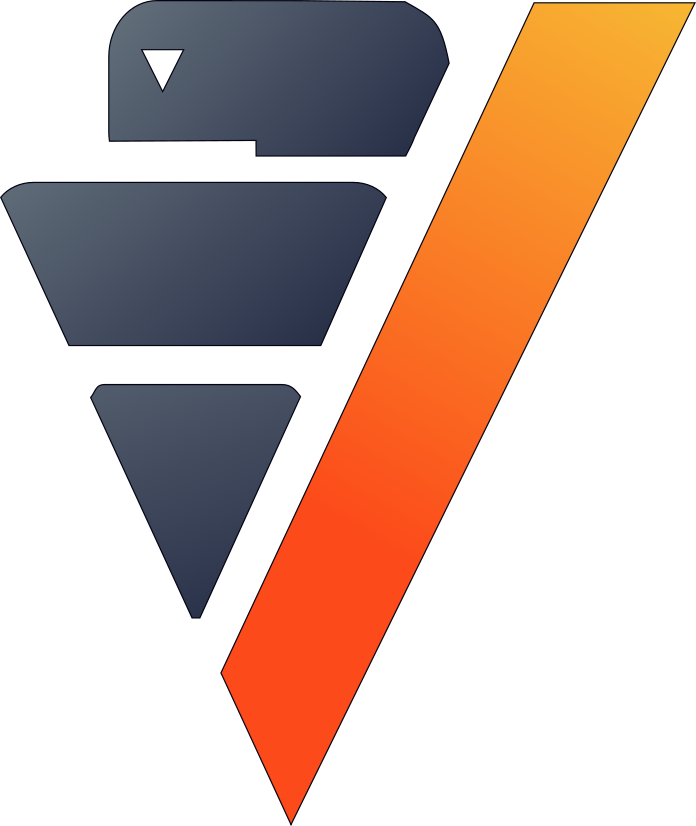

PREDICT_RF_CLASSIFIER("vib_vs_baseline", "temp_vs_baseline", "psi_vs_baseline", "vib_trend_2d", "temp_trend_2d", "psi_trend_2d", "max_vib", "max_motor_temp", "min_psi", "hb_100km", "avg_out_temp" USING PARAMETERS model_name = 'FLEET.vpy_pdm_rf', match_by_pos = 'true') ...


In [32]:
display(vp.vDataFrame("SELECT model_name, model_type, create_time::timestamp(0) AS created, (size / 1024)::int AS size_kb FROM models WHERE schema_name = 'FLEET' ORDER BY create_time"))
print(rf.deploySQL()[:300] + " ...")

---
*Clean-up:* `DROP SCHEMA FLEET CASCADE;` removes every table, view and model of this demo.